# Fruit Classification CNN

In [1]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [12]:
from torchvision import datasets, transforms

batch_size = 32

transform = transforms.Compose([
    transforms.Resize(150),  # Resize shortest side to 150
    transforms.CenterCrop((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_data = datasets.ImageFolder(root='Fruit_dataset/train1', transform=transform)
print(len(train_data))

val_data = datasets.ImageFolder(root='Fruit_dataset/val1', transform=transform)
print(len(val_data))

test_data = datasets.ImageFolder(root='Fruit_dataset/test1', transform=transform)
print(len(test_data))

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

40000
5000
5000


In [13]:
import matplotlib.pyplot as plt

def imshow(img):
  img = img / 2 + 0.5
  plt.imshow(np.transpose(img, (1, 2, 0)))
  

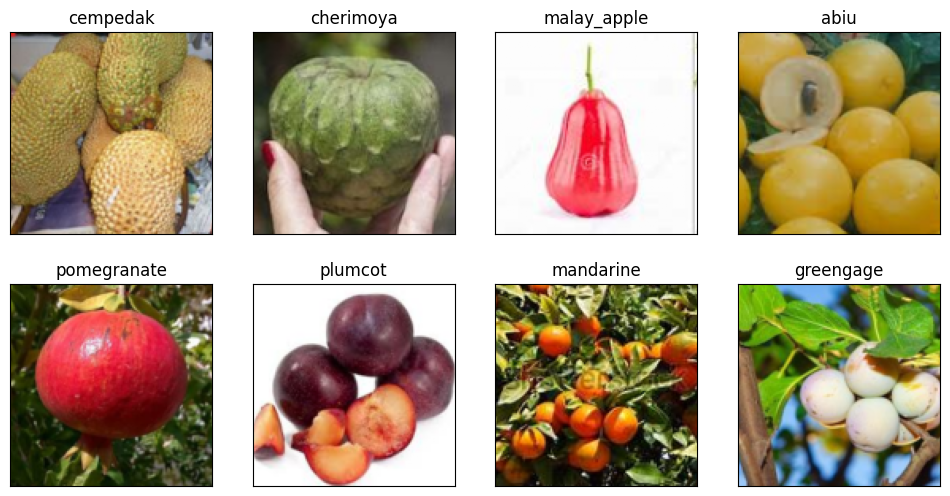

In [14]:
classes = train_data.classes

dataiter = iter(train_loader)

images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

images, labels = next(dataiter)

fig = plt.figure(figsize=(12, 6))
for idx in range(8):
  ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
  imshow(images[idx])
  ax.set_title(classes[labels[idx]])

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()

    # TODO: build CNN


model = Net()
print(model)

if(train_on_gpu):
  model.cuda()
